# Hospitality Revenue Analysis

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Environment ready!")

Environment ready!


## 2. Load Datasets

In [3]:
bookings = pd.read_csv("fact_bookings.csv")
bookings.head()


,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
0,May012216558RT11,16558,2022-04-27,2022-05-01,2022-05-02,3,RT1,direct online,1.0,Checked Out,10010,10010
1,May012216558RT12,16558,2022-04-30,2022-05-01,2022-05-02,2,RT1,others,NaN,Cancelled,9100,3640
2,May012216558RT13,16558,2022-04-28,2022-05-01,2022-05-04,2,RT1,logtrip,5.0,Checked Out,9100,9100
3,May012216558RT14,16558,2022-04-28,2022-05-01,2022-05-02,2,RT1,others,NaN,Cancelled,9100,3640
4,May012216558RT15,16558,2022-04-27,2022-05-01,2022-05-02,4,RT1,direct online,5.0,Checked Out,10920,10920


## 3. Data Understanding

In [4]:
bookings.shape

(134590, 12)

In [5]:
bookings.columns

Index(['booking_id', 'property_id', 'booking_date', 'check_in_date',
       'checkout_date', 'no_guests', 'room_category', 'booking_platform',
       'ratings_given', 'booking_status', 'revenue_generated',
       'revenue_realized'],
      dtype='str')

In [6]:
bookings.info()

<class 'pandas.DataFrame'>
RangeIndex: 134590 entries, 0 to 134589
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   booking_id         134590 non-null  str    
 1   property_id        134590 non-null  int64  
 2   booking_date       134590 non-null  str    
 3   check_in_date      134590 non-null  str    
 4   checkout_date      134590 non-null  str    
 5   no_guests          134590 non-null  int64  
 6   room_category      134590 non-null  str    
 7   booking_platform   134590 non-null  str    
 8   ratings_given      56683 non-null   float64
 9   booking_status     134590 non-null  str    
 10  revenue_generated  134590 non-null  int64  
 11  revenue_realized   134590 non-null  int64  
dtypes: float64(1), int64(4), str(7)
memory usage: 12.3 MB


## 4. Data Quality Checks

In [7]:
bookings.isnull().sum()

booking_id               0
property_id              0
booking_date             0
check_in_date            0
checkout_date            0
no_guests                0
room_category            0
booking_platform         0
ratings_given        77907
booking_status           0
revenue_generated        0
revenue_realized         0
dtype: int64

In [8]:
bookings.duplicated().sum()

np.int64(0)

In [9]:
bookings.describe()

,property_id,no_guests,ratings_given,revenue_generated,revenue_realized
count,134590.000000,134590.000000,56683.000000,134590.000000,134590.000000
mean,18061.113493,2.036808,3.619004,14916.013188,12696.123256
std,1093.055847,1.031766,1.235009,6452.868072,6928.108124
min,16558.000000,1.000000,1.000000,6500.000000,2600.000000
25%,17558.000000,1.000000,3.000000,9900.000000,7600.000000
50%,17564.000000,2.000000,4.000000,13500.000000,11700.000000
75%,18563.000000,2.000000,5.000000,18000.000000,15300.000000
max,19563.000000,6.000000,5.000000,45220.000000,45220.000000


In [10]:
bookings.columns.tolist()

['booking_id',
 'property_id',
 'booking_date',
 'check_in_date',
 'checkout_date',
 'no_guests',
 'room_category',
 'booking_platform',
 'ratings_given',
 'booking_status',
 'revenue_generated',
 'revenue_realized']

In [11]:
bookings.dtypes

booking_id               str
property_id            int64
booking_date             str
check_in_date            str
checkout_date            str
no_guests              int64
room_category            str
booking_platform         str
ratings_given        float64
booking_status           str
revenue_generated      int64
revenue_realized       int64
dtype: object

In [13]:
bookings.isnull().sum()

booking_id               0
property_id              0
booking_date             0
check_in_date            0
checkout_date            0
no_guests                0
room_category            0
booking_platform         0
ratings_given        77907
booking_status           0
revenue_generated        0
revenue_realized         0
dtype: int64

In [14]:
bookings['ratings_given'].isnull().sum()

np.int64(77907)

In [15]:
bookings['ratings_given'].isnull().mean() * 100

np.float64(57.884686826658736)

In [16]:
bookings.groupby('booking_status')['ratings_given'].apply(
    lambda x: x.isnull().sum()
)

booking_status
Cancelled      33420
Checked Out    37728
No Show         6759
Name: ratings_given, dtype: int64

In [17]:
bookings['booking_status'].value_counts()

booking_status
Checked Out    94411
Cancelled      33420
No Show         6759
Name: count, dtype: int64

In [18]:
bookings['booking_status'].value_counts(normalize=True) * 100

booking_status
Checked Out    70.147113
Cancelled      24.830968
No Show         5.021918
Name: proportion, dtype: float64

In [19]:
bookings[['booking_date', 'check_in_date', 'checkout_date']].head(10)

,booking_date,check_in_date,checkout_date
0,2022-04-27,2022-05-01,2022-05-02
1,2022-04-30,2022-05-01,2022-05-02
2,2022-04-28,2022-05-01,2022-05-04
3,2022-04-28,2022-05-01,2022-05-02
4,2022-04-27,2022-05-01,2022-05-02
5,2022-05-01,2022-05-01,2022-05-03
6,2022-04-28,2022-05-01,2022-05-06
7,2022-04-26,2022-05-01,2022-05-03
8,2022-04-30,2022-05-01,2022-05-02
9,2022-04-28,2022-05-01,2022-05-02


In [20]:
bookings[['booking_date', 'check_in_date', 'checkout_date']].dtypes

booking_date     str
check_in_date    str
checkout_date    str
dtype: object

In [21]:
bookings_clean = bookings.copy()

In [22]:
date_columns = ['booking_date', 'check_in_date', 'checkout_date']

for col in date_columns:
    bookings_clean[col] = pd.to_datetime(bookings_clean[col])

In [23]:
bookings_clean[date_columns].dtypes

booking_date     datetime64[us]
check_in_date    datetime64[us]
checkout_date    datetime64[us]
dtype: object

In [24]:
bookings_clean[['booking_date', 'check_in_date', 'checkout_date']].describe()

,booking_date,check_in_date,checkout_date
count,134590,134590,134590
mean,2022-06-11 05:51:49.871462,2022-06-14 22:52:29.939817,2022-06-17 07:51:51.262352
min,2022-04-07 00:00:00,2022-05-01 00:00:00,2022-05-02 00:00:00
25%,2022-05-19 00:00:00,2022-05-23 00:00:00,2022-05-25 00:00:00
50%,2022-06-11 00:00:00,2022-06-15 00:00:00,2022-06-17 00:00:00
75%,2022-07-04 00:00:00,2022-07-08 00:00:00,2022-07-10 00:00:00
max,2022-07-31 00:00:00,2022-07-31 00:00:00,2022-08-06 00:00:00


## 5. Data Cleaning

In [25]:
(bookings_clean['checkout_date'] < bookings_clean['check_in_date']).sum()


np.int64(0)

In [26]:
bookings[['booking_date', 'check_in_date', 'checkout_date']].head(10)

,booking_date,check_in_date,checkout_date
0,2022-04-27,2022-05-01,2022-05-02
1,2022-04-30,2022-05-01,2022-05-02
2,2022-04-28,2022-05-01,2022-05-04
3,2022-04-28,2022-05-01,2022-05-02
4,2022-04-27,2022-05-01,2022-05-02
5,2022-05-01,2022-05-01,2022-05-03
6,2022-04-28,2022-05-01,2022-05-06
7,2022-04-26,2022-05-01,2022-05-03
8,2022-04-30,2022-05-01,2022-05-02
9,2022-04-28,2022-05-01,2022-05-02


In [27]:
bookings[['booking_date', 'check_in_date', 'checkout_date']].dtypes

booking_date     str
check_in_date    str
checkout_date    str
dtype: object

In [28]:
bookings_clean = bookings.copy()

date_columns = ['booking_date', 'check_in_date', 'checkout_date']

for col in date_columns:
    bookings_clean[col] = pd.to_datetime(bookings_clean[col])

In [29]:
bookings_clean[date_columns].dtypes

booking_date     datetime64[us]
check_in_date    datetime64[us]
checkout_date    datetime64[us]
dtype: object

In [30]:
(bookings_clean['checkout_date'] < bookings_clean['check_in_date']).sum()

np.int64(0)

In [31]:
(bookings_clean['booking_date'] > bookings_clean['check_in_date']).sum()

np.int64(0)

In [32]:
bookings_clean['stay_duration'] = (
    bookings_clean['checkout_date'] - bookings_clean['check_in_date']
).dt.days

In [33]:
bookings_clean['stay_duration'].describe()

count    134590.000000
mean          2.374552
std           1.733514
min           1.000000
25%           1.000000
50%           2.000000
75%           3.000000
max           6.000000
Name: stay_duration, dtype: float64

In [34]:
(bookings_clean['stay_duration'] <= 0).sum()

np.int64(0)

In [35]:
bookings_clean['booking_status'].value_counts()


booking_status
Checked Out    94411
Cancelled      33420
No Show         6759
Name: count, dtype: int64

In [36]:
bookings_clean['booking_status'].value_counts(normalize=True) * 100

booking_status
Checked Out    70.147113
Cancelled      24.830968
No Show         5.021918
Name: proportion, dtype: float64

In [37]:
bookings_clean.groupby('booking_status')['revenue_generated'].agg(
    ['count', 'sum', 'mean']
)

,count,sum,mean
booking_status,,,
Cancelled,33420,497958310,14900.009276
Checked Out,94411,1409113965,14925.315535
No Show,6759,100473940,14865.207871


In [38]:
bookings_clean[['revenue_generated', 'revenue_realized']].sum()

revenue_generated    2007546215
revenue_realized     1708771229
dtype: int64

In [39]:
revenue_difference = (
    bookings_clean['revenue_generated'].sum()
    - bookings_clean['revenue_realized'].sum()
)

revenue_difference

np.int64(298774986)

In [40]:
realization_rate = (
    bookings_clean['revenue_realized'].sum()
    / bookings_clean['revenue_generated'].sum()
) * 100

realization_rate

np.float64(85.11740433332939)

In [41]:
revenue_by_status = bookings_clean.groupby('booking_status').agg(
    bookings=('booking_id', 'count'),
    revenue_generated=('revenue_generated', 'sum'),
    revenue_realized=('revenue_realized', 'sum')
)

revenue_by_status['revenue_gap'] = (
    revenue_by_status['revenue_generated']
    - revenue_by_status['revenue_realized']
)

revenue_by_status

,bookings,revenue_generated,revenue_realized,revenue_gap
booking_status,,,,
Cancelled,33420,497958310,199183324,298774986
Checked Out,94411,1409113965,1409113965,0
No Show,6759,100473940,100473940,0


In [42]:
revenue_by_status['realization_rate'] = (
    revenue_by_status['revenue_realized']
    / revenue_by_status['revenue_generated']
) * 100

revenue_by_status.sort_values(
    'revenue_gap',
    ascending=False
)

,bookings,revenue_generated,revenue_realized,revenue_gap,realization_rate
booking_status,,,,,
Cancelled,33420,497958310,199183324,298774986,40.0
Checked Out,94411,1409113965,1409113965,0,100.0
No Show,6759,100473940,100473940,0,100.0


In [44]:
platform_analysis = bookings_clean.groupby('booking_platform').agg(
    bookings=('booking_id', 'count'),
    revenue_generated=('revenue_generated', 'sum'),
    revenue_realized=('revenue_realized', 'sum')
)

platform_analysis['realization_rate'] = (
    platform_analysis['revenue_realized']
    / platform_analysis['revenue_generated']
) * 100

platform_analysis.sort_values(
    'revenue_realized',
    ascending=False
)

,bookings,revenue_generated,revenue_realized,realization_rate
booking_platform,,,,
others,55066,821066620,699353302,85.176195
makeyourtrip,26898,401502130,340834504,84.889837
logtrip,14756,219478955,187554488,85.454429
direct online,13379,198770030,169026467,85.036193
tripster,9630,144714510,123066801,85.041093
journey,8106,120654715,102531334,84.979136
direct offline,6755,101359255,86404333,85.245628


## 6. Booking & Revenue Analysis

In [45]:
platform_analysis['revenue_per_booking'] = (
    platform_analysis['revenue_realized']
    / platform_analysis['bookings']
)

platform_analysis.sort_values(
    'revenue_per_booking',
    ascending=False
)

,bookings,revenue_generated,revenue_realized,realization_rate,revenue_per_booking
booking_platform,,,,,
direct offline,6755,101359255,86404333,85.245628,12791.166987
tripster,9630,144714510,123066801,85.041093,12779.522430
logtrip,14756,219478955,187554488,85.454429,12710.388181
others,55066,821066620,699353302,85.176195,12700.274253
makeyourtrip,26898,401502130,340834504,84.889837,12671.369767
journey,8106,120654715,102531334,84.979136,12648.819887
direct online,13379,198770030,169026467,85.036193,12633.714553


In [46]:
platform_analysis[
    ['bookings', 'revenue_generated', 'revenue_realized',
     'realization_rate', 'revenue_per_booking']
].sort_values(
    'revenue_per_booking',
    ascending=False
)

,bookings,revenue_generated,revenue_realized,realization_rate,revenue_per_booking
booking_platform,,,,,
direct offline,6755,101359255,86404333,85.245628,12791.166987
tripster,9630,144714510,123066801,85.041093,12779.522430
logtrip,14756,219478955,187554488,85.454429,12710.388181
others,55066,821066620,699353302,85.176195,12700.274253
makeyourtrip,26898,401502130,340834504,84.889837,12671.369767
journey,8106,120654715,102531334,84.979136,12648.819887
direct online,13379,198770030,169026467,85.036193,12633.714553


In [47]:
platform_analysis['revenue_per_booking'] = (
    platform_analysis['revenue_realized']
    / platform_analysis['bookings']
)

platform_analysis[
    ['bookings', 'revenue_generated', 'revenue_realized',
     'realization_rate', 'revenue_per_booking']
].sort_values(
    'revenue_per_booking',
    ascending=False
)

,bookings,revenue_generated,revenue_realized,realization_rate,revenue_per_booking
booking_platform,,,,,
direct offline,6755,101359255,86404333,85.245628,12791.166987
tripster,9630,144714510,123066801,85.041093,12779.522430
logtrip,14756,219478955,187554488,85.454429,12710.388181
others,55066,821066620,699353302,85.176195,12700.274253
makeyourtrip,26898,401502130,340834504,84.889837,12671.369767
journey,8106,120654715,102531334,84.979136,12648.819887
direct online,13379,198770030,169026467,85.036193,12633.714553


In [48]:
platform_analysis[
    ['bookings',
     'revenue_generated',
     'revenue_realized',
     'realization_rate',
     'revenue_per_booking']
].sort_values(
    'revenue_per_booking',
    ascending=False
).round(2)

,bookings,revenue_generated,revenue_realized,realization_rate,revenue_per_booking
booking_platform,,,,,
direct offline,6755,101359255,86404333,85.25,12791.17
tripster,9630,144714510,123066801,85.04,12779.52
logtrip,14756,219478955,187554488,85.45,12710.39
others,55066,821066620,699353302,85.18,12700.27
makeyourtrip,26898,401502130,340834504,84.89,12671.37
journey,8106,120654715,102531334,84.98,12648.82
direct online,13379,198770030,169026467,85.04,12633.71


In [49]:
platform_analysis[
    ['realization_rate', 'revenue_per_booking']
].sort_values(
    'revenue_per_booking',
    ascending=False
).round(2)

,realization_rate,revenue_per_booking
booking_platform,,
direct offline,85.25,12791.17
tripster,85.04,12779.52
logtrip,85.45,12710.39
others,85.18,12700.27
makeyourtrip,84.89,12671.37
journey,84.98,12648.82
direct online,85.04,12633.71


In [50]:
room_analysis = bookings_clean.groupby('room_category').agg(
    bookings=('booking_id', 'count'),
    revenue_generated=('revenue_generated', 'sum'),
    revenue_realized=('revenue_realized', 'sum')
)

room_analysis['revenue_per_booking'] = (
    room_analysis['revenue_realized']
    / room_analysis['bookings']
)

room_analysis['realization_rate'] = (
    room_analysis['revenue_realized']
    / room_analysis['revenue_generated']
) * 100

room_analysis.sort_values(
    'revenue_realized',
    ascending=False
).round(2)

,bookings,revenue_generated,revenue_realized,revenue_per_booking,realization_rate
room_category,,,,,
RT2,49505,658946160,560271204,11317.47,85.03
RT3,30566,543597840,462166344,15120.28,85.02
RT4,16073,441457020,376752786,23440.10,85.34
RT1,38446,363545195,309580895,8052.36,85.16


## 7. Booking Platform Analysis

In [51]:
room_analysis[
    [
        'bookings',
        'revenue_generated',
        'revenue_realized',
        'revenue_per_booking',
        'realization_rate'
    ]
].sort_values(
    'revenue_per_booking',
    ascending=False
).round(2)

,bookings,revenue_generated,revenue_realized,revenue_per_booking,realization_rate
room_category,,,,,
RT4,16073,441457020,376752786,23440.10,85.34
RT3,30566,543597840,462166344,15120.28,85.02
RT2,49505,658946160,560271204,11317.47,85.03
RT1,38446,363545195,309580895,8052.36,85.16


In [52]:
room_analysis[
    ['realization_rate']
].sort_values(
    'realization_rate',
    ascending=False
).round(2)

,realization_rate
room_category,
RT4,85.34
RT1,85.16
RT2,85.03
RT3,85.02


In [53]:
hotels = pd.read_csv("dim_hotels.csv")
rooms = pd.read_csv("dim_rooms.csv")
dates = pd.read_csv("dim_date.csv")
aggregated_bookings = pd.read_csv("fact_aggregated_bookings.csv")

## 8. Hotel Analysis

In [54]:
print("HOTELS")
display(hotels.head())

print("ROOMS")
display(rooms.head())

print("DATES")
display(dates.head())

print("AGGREGATED BOOKINGS")
display(aggregated_bookings.head())

HOTELS


,property_id,property_name,category,city
0,16558,Atliq Grands,Luxury,Delhi
1,16559,Atliq Exotica,Luxury,Mumbai
2,16560,Atliq City,Business,Delhi
3,16561,Atliq Blu,Luxury,Delhi
4,16562,Atliq Bay,Luxury,Delhi


ROOMS


,room_id,room_class
0,RT1,Standard
1,RT2,Elite
2,RT3,Premium
3,RT4,Presidential


DATES


,date,mmm yy,week no,day_type
0,01-May-22,May 22,W 19,weekend
1,02-May-22,May 22,W 19,weekeday
2,03-May-22,May 22,W 19,weekeday
3,04-May-22,May 22,W 19,weekeday
4,05-May-22,May 22,W 19,weekeday


AGGREGATED BOOKINGS


,property_id,check_in_date,room_category,successful_bookings,capacity
0,16559,01-May-22,RT1,25,30
1,19562,01-May-22,RT1,28,30
2,19563,01-May-22,RT1,23,30
3,17558,01-May-22,RT1,13,19
4,16558,01-May-22,RT1,18,19


In [55]:
print("Hotels:", hotels.shape)
print("Rooms:", rooms.shape)
print("Dates:", dates.shape)
print("Aggregated Bookings:", aggregated_bookings.shape)

Hotels: (25, 4)
Rooms: (4, 2)
Dates: (92, 4)
Aggregated Bookings: (9200, 5)


In [56]:
print("HOTELS COLUMNS")
print(hotels.columns.tolist())

print("\nROOMS COLUMNS")
print(rooms.columns.tolist())

print("\nDATES COLUMNS")
print(dates.columns.tolist())

print("\nAGGREGATED BOOKINGS COLUMNS")
print(aggregated_bookings.columns.tolist())

HOTELS COLUMNS
['property_id', 'property_name', 'category', 'city']

ROOMS COLUMNS
['room_id', 'room_class']

DATES COLUMNS
['date', 'mmm yy', 'week no', 'day_type']

AGGREGATED BOOKINGS COLUMNS
['property_id', 'check_in_date', 'room_category', 'successful_bookings', 'capacity']


In [57]:
print("HOTELS")
print(hotels.dtypes)

print("\nROOMS")
print(rooms.dtypes)

print("\nDATES")
print(dates.dtypes)

print("\nAGGREGATED BOOKINGS")
print(aggregated_bookings.dtypes)

HOTELS
property_id      int64
property_name      str
category           str
city               str
dtype: object

ROOMS
room_id       str
room_class    str
dtype: object

DATES
date        str
mmm yy      str
week no     str
day_type    str
dtype: object

AGGREGATED BOOKINGS
property_id            int64
check_in_date            str
room_category            str
successful_bookings    int64
capacity               int64
dtype: object


## 9. Room Category Analysis

In [58]:
hotels.head()

,property_id,property_name,category,city
0,16558,Atliq Grands,Luxury,Delhi
1,16559,Atliq Exotica,Luxury,Mumbai
2,16560,Atliq City,Business,Delhi
3,16561,Atliq Blu,Luxury,Delhi
4,16562,Atliq Bay,Luxury,Delhi


In [59]:
hotels.columns.tolist()

['property_id', 'property_name', 'category', 'city']

In [60]:
hotels.shape

(25, 4)

In [61]:
hotels['property_id'].duplicated().sum()

np.int64(0)

In [62]:
hotels.isnull().sum()

property_id      0
property_name    0
category         0
city             0
dtype: int64

In [63]:
hotel_bookings = bookings_clean.merge(
    hotels,
    on='property_id',
    how='left'
)

In [64]:
hotel_bookings.shape

(134590, 16)

In [65]:
hotel_bookings['property_name'].isnull().sum()

np.int64(0)

In [66]:
hotel_bookings['property_id'].nunique()

25

## 10. Monthly Analysis

In [67]:
hotel_analysis = hotel_bookings.groupby(
    ['property_id', 'property_name', 'category', 'city']
).agg(
    bookings=('booking_id', 'count'),
    revenue_generated=('revenue_generated', 'sum'),
    revenue_realized=('revenue_realized', 'sum')
).reset_index()

In [68]:
hotel_analysis['revenue_gap'] = (
    hotel_analysis['revenue_generated']
    - hotel_analysis['revenue_realized']
)

hotel_analysis['realization_rate'] = (
    hotel_analysis['revenue_realized']
    / hotel_analysis['revenue_generated']
) * 100

In [69]:
hotel_analysis.sort_values(
    'revenue_realized',
    ascending=False
).head(10).round(2)

,property_id,property_name,category,city,bookings,revenue_generated,revenue_realized,revenue_gap,realization_rate
1,16559,Atliq Exotica,Luxury,Mumbai,7338,138698580,118448418,20250162,85.40
11,17563,Atliq Palace,Business,Mumbai,6337,118616735,101511080,17105655,85.58
7,17559,Atliq Exotica,Luxury,Mumbai,6142,109696920,93996570,15700350,85.69
5,16563,Atliq Palace,Business,Delhi,7147,105200620,89135998,16064622,84.73
8,17560,Atliq City,Business,Mumbai,6013,103776330,87996216,15780114,84.79
23,19562,Atliq Bay,Luxury,Bangalore,5812,96540375,82443540,14096835,85.40
21,19560,Atliq City,Business,Bangalore,5979,97486125,81876345,15609780,83.99
6,17558,Atliq Grands,Luxury,Mumbai,5036,88430770,74730742,13700028,84.51
9,17561,Atliq Blu,Luxury,Mumbai,5183,86646790,73918312,12728478,85.31
22,19561,Atliq Blu,Luxury,Bangalore,5736,85807575,72963360,12844215,85.03


In [70]:
hotel_analysis.sort_values(
    'revenue_gap',
    ascending=False
).head(10).round(2)

,property_id,property_name,category,city,bookings,revenue_generated,revenue_realized,revenue_gap,realization_rate
1,16559,Atliq Exotica,Luxury,Mumbai,7338,138698580,118448418,20250162,85.40
11,17563,Atliq Palace,Business,Mumbai,6337,118616735,101511080,17105655,85.58
5,16563,Atliq Palace,Business,Delhi,7147,105200620,89135998,16064622,84.73
8,17560,Atliq City,Business,Mumbai,6013,103776330,87996216,15780114,84.79
7,17559,Atliq Exotica,Luxury,Mumbai,6142,109696920,93996570,15700350,85.69
21,19560,Atliq City,Business,Bangalore,5979,97486125,81876345,15609780,83.99
23,19562,Atliq Bay,Luxury,Bangalore,5812,96540375,82443540,14096835,85.40
6,17558,Atliq Grands,Luxury,Mumbai,5036,88430770,74730742,13700028,84.51
22,19561,Atliq Blu,Luxury,Bangalore,5736,85807575,72963360,12844215,85.03
9,17561,Atliq Blu,Luxury,Mumbai,5183,86646790,73918312,12728478,85.31


In [71]:
hotels['property_id'].duplicated().sum()

np.int64(0)

In [72]:
hotels.isnull().sum()

property_id      0
property_name    0
category         0
city             0
dtype: int64

In [73]:
hotel_bookings = bookings_clean.merge(
    hotels,
    on='property_id',
    how='left'
)

In [74]:
hotel_bookings.shape

(134590, 16)

In [75]:
hotel_bookings['property_name'].isnull().sum()

np.int64(0)

In [76]:
hotel_analysis = hotel_bookings.groupby(
    ['property_id', 'property_name', 'category', 'city']
).agg(
    bookings=('booking_id', 'count'),
    revenue_generated=('revenue_generated', 'sum'),
    revenue_realized=('revenue_realized', 'sum')
).reset_index()

In [77]:
hotel_analysis['revenue_gap'] = (
    hotel_analysis['revenue_generated']
    - hotel_analysis['revenue_realized']
)

hotel_analysis['realization_rate'] = (
    hotel_analysis['revenue_realized']
    / hotel_analysis['revenue_generated']
) * 100

## 11. Occupancy Analysis

In [78]:
hotel_analysis.sort_values(
    'revenue_realized',
    ascending=False
).head(10).round(2)

,property_id,property_name,category,city,bookings,revenue_generated,revenue_realized,revenue_gap,realization_rate
1,16559,Atliq Exotica,Luxury,Mumbai,7338,138698580,118448418,20250162,85.40
11,17563,Atliq Palace,Business,Mumbai,6337,118616735,101511080,17105655,85.58
7,17559,Atliq Exotica,Luxury,Mumbai,6142,109696920,93996570,15700350,85.69
5,16563,Atliq Palace,Business,Delhi,7147,105200620,89135998,16064622,84.73
8,17560,Atliq City,Business,Mumbai,6013,103776330,87996216,15780114,84.79
23,19562,Atliq Bay,Luxury,Bangalore,5812,96540375,82443540,14096835,85.40
21,19560,Atliq City,Business,Bangalore,5979,97486125,81876345,15609780,83.99
6,17558,Atliq Grands,Luxury,Mumbai,5036,88430770,74730742,13700028,84.51
9,17561,Atliq Blu,Luxury,Mumbai,5183,86646790,73918312,12728478,85.31
22,19561,Atliq Blu,Luxury,Bangalore,5736,85807575,72963360,12844215,85.03


In [79]:
hotel_analysis.sort_values(
    'revenue_gap',
    ascending=False
).head(10).round(2)

,property_id,property_name,category,city,bookings,revenue_generated,revenue_realized,revenue_gap,realization_rate
1,16559,Atliq Exotica,Luxury,Mumbai,7338,138698580,118448418,20250162,85.40
11,17563,Atliq Palace,Business,Mumbai,6337,118616735,101511080,17105655,85.58
5,16563,Atliq Palace,Business,Delhi,7147,105200620,89135998,16064622,84.73
8,17560,Atliq City,Business,Mumbai,6013,103776330,87996216,15780114,84.79
7,17559,Atliq Exotica,Luxury,Mumbai,6142,109696920,93996570,15700350,85.69
21,19560,Atliq City,Business,Bangalore,5979,97486125,81876345,15609780,83.99
23,19562,Atliq Bay,Luxury,Bangalore,5812,96540375,82443540,14096835,85.40
6,17558,Atliq Grands,Luxury,Mumbai,5036,88430770,74730742,13700028,84.51
22,19561,Atliq Blu,Luxury,Bangalore,5736,85807575,72963360,12844215,85.03
9,17561,Atliq Blu,Luxury,Mumbai,5183,86646790,73918312,12728478,85.31


In [80]:
hotel_analysis.sort_values(
    'revenue_realized',
    ascending=False
).head(10).round(2)

,property_id,property_name,category,city,bookings,revenue_generated,revenue_realized,revenue_gap,realization_rate
1,16559,Atliq Exotica,Luxury,Mumbai,7338,138698580,118448418,20250162,85.40
11,17563,Atliq Palace,Business,Mumbai,6337,118616735,101511080,17105655,85.58
7,17559,Atliq Exotica,Luxury,Mumbai,6142,109696920,93996570,15700350,85.69
5,16563,Atliq Palace,Business,Delhi,7147,105200620,89135998,16064622,84.73
8,17560,Atliq City,Business,Mumbai,6013,103776330,87996216,15780114,84.79
23,19562,Atliq Bay,Luxury,Bangalore,5812,96540375,82443540,14096835,85.40
21,19560,Atliq City,Business,Bangalore,5979,97486125,81876345,15609780,83.99
6,17558,Atliq Grands,Luxury,Mumbai,5036,88430770,74730742,13700028,84.51
9,17561,Atliq Blu,Luxury,Mumbai,5183,86646790,73918312,12728478,85.31
22,19561,Atliq Blu,Luxury,Bangalore,5736,85807575,72963360,12844215,85.03


In [81]:
hotel_analysis.sort_values(
    'revenue_gap',
    ascending=False
).head(10).round(2)

,property_id,property_name,category,city,bookings,revenue_generated,revenue_realized,revenue_gap,realization_rate
1,16559,Atliq Exotica,Luxury,Mumbai,7338,138698580,118448418,20250162,85.40
11,17563,Atliq Palace,Business,Mumbai,6337,118616735,101511080,17105655,85.58
5,16563,Atliq Palace,Business,Delhi,7147,105200620,89135998,16064622,84.73
8,17560,Atliq City,Business,Mumbai,6013,103776330,87996216,15780114,84.79
7,17559,Atliq Exotica,Luxury,Mumbai,6142,109696920,93996570,15700350,85.69
21,19560,Atliq City,Business,Bangalore,5979,97486125,81876345,15609780,83.99
23,19562,Atliq Bay,Luxury,Bangalore,5812,96540375,82443540,14096835,85.40
6,17558,Atliq Grands,Luxury,Mumbai,5036,88430770,74730742,13700028,84.51
22,19561,Atliq Blu,Luxury,Bangalore,5736,85807575,72963360,12844215,85.03
9,17561,Atliq Blu,Luxury,Mumbai,5183,86646790,73918312,12728478,85.31


In [82]:
city_analysis = hotel_bookings.groupby('city').agg(
    bookings=('booking_id', 'count'),
    revenue_generated=('revenue_generated', 'sum'),
    revenue_realized=('revenue_realized', 'sum')
).reset_index()

In [83]:
city_analysis['revenue_gap'] = (
    city_analysis['revenue_generated']
    - city_analysis['revenue_realized']
)

city_analysis['realization_rate'] = (
    city_analysis['revenue_realized']
    / city_analysis['revenue_generated']
) * 100

In [84]:
city_analysis.sort_values(
    'revenue_realized',
    ascending=False
).round(2)

,city,bookings,revenue_generated,revenue_realized,revenue_gap,realization_rate
3,Mumbai,43455,784865350,668640991,116224359,85.19
0,Bangalore,32016,494828175,420397050,74431125,84.96
2,Hyderabad,34888,381400850,325232870,56167980,85.27
1,Delhi,24231,346451840,294500318,51951522,85.00


In [85]:
category_analysis = hotel_bookings.groupby('category').agg(
    bookings=('booking_id', 'count'),
    revenue_generated=('revenue_generated', 'sum'),
    revenue_realized=('revenue_realized', 'sum')
).reset_index()

category_analysis['revenue_gap'] = (
    category_analysis['revenue_generated']
    - category_analysis['revenue_realized']
)

category_analysis['realization_rate'] = (
    category_analysis['revenue_realized']
    / category_analysis['revenue_generated']
) * 100

category_analysis.round(2)

,category,bookings,revenue_generated,revenue_realized,revenue_gap,realization_rate
0,Business,50930,772208925,656019297,116189628,84.95
1,Luxury,83660,1235337290,1052751932,182585358,85.22


In [86]:
rooms.head()

,room_id,room_class
0,RT1,Standard
1,RT2,Elite
2,RT3,Premium
3,RT4,Presidential


In [87]:
rooms.columns.tolist()

['room_id', 'room_class']

In [88]:
rooms.shape

(4, 2)

In [89]:
rooms.isnull().sum()

room_id       0
room_class    0
dtype: int64

In [90]:
rooms.head()

,room_id,room_class
0,RT1,Standard
1,RT2,Elite
2,RT3,Premium
3,RT4,Presidential


In [91]:
rooms.columns.tolist()

['room_id', 'room_class']

In [92]:
rooms.shape

(4, 2)

In [93]:
rooms.isnull().sum()

room_id       0
room_class    0
dtype: int64

In [94]:
rooms

,room_id,room_class
0,RT1,Standard
1,RT2,Elite
2,RT3,Premium
3,RT4,Presidential


In [95]:
bookings_clean['room_category'].unique()

<StringArray>
['RT1', 'RT2', 'RT3', 'RT4']
Length: 4, dtype: str

In [96]:
room_bookings = bookings_clean.merge(
    rooms,
    left_on='room_category',
    right_on='room_id',
    how='left'
)

In [97]:
room_bookings['room_class'].isnull().sum()

np.int64(0)

In [98]:
bookings_clean['room_category'].unique()

<StringArray>
['RT1', 'RT2', 'RT3', 'RT4']
Length: 4, dtype: str

In [99]:
room_bookings['room_class'].isnull().sum()

np.int64(0)

In [100]:
rooms

,room_id,room_class
0,RT1,Standard
1,RT2,Elite
2,RT3,Premium
3,RT4,Presidential


In [101]:
room_class_analysis = room_bookings.groupby(
    ['room_id', 'room_class']
).agg(
    bookings=('booking_id', 'count'),
    revenue_generated=('revenue_generated', 'sum'),
    revenue_realized=('revenue_realized', 'sum')
).reset_index()

In [102]:
room_class_analysis['revenue_gap'] = (
    room_class_analysis['revenue_generated']
    - room_class_analysis['revenue_realized']
)

room_class_analysis['realization_rate'] = (
    room_class_analysis['revenue_realized']
    / room_class_analysis['revenue_generated']
) * 100

room_class_analysis['revenue_per_booking'] = (
    room_class_analysis['revenue_realized']
    / room_class_analysis['bookings']
)

In [103]:
room_class_analysis.sort_values(
    'revenue_realized',
    ascending=False
).round(2)

,room_id,room_class,bookings,revenue_generated,revenue_realized,revenue_gap,realization_rate,revenue_per_booking
1,RT2,Elite,49505,658946160,560271204,98674956,85.03,11317.47
2,RT3,Premium,30566,543597840,462166344,81431496,85.02,15120.28
3,RT4,Presidential,16073,441457020,376752786,64704234,85.34,23440.10
0,RT1,Standard,38446,363545195,309580895,53964300,85.16,8052.36


In [104]:
room_class_analysis = room_bookings.groupby(
    ['room_id', 'room_class']
).agg(
    bookings=('booking_id', 'count'),
    revenue_generated=('revenue_generated', 'sum'),
    revenue_realized=('revenue_realized', 'sum')
).reset_index()

In [105]:
room_class_analysis['revenue_gap'] = (
    room_class_analysis['revenue_generated']
    - room_class_analysis['revenue_realized']
)

room_class_analysis['realization_rate'] = (
    room_class_analysis['revenue_realized']
    / room_class_analysis['revenue_generated']
) * 100

room_class_analysis['revenue_per_booking'] = (
    room_class_analysis['revenue_realized']
    / room_class_analysis['bookings']
)

In [106]:
room_class_analysis.sort_values(
    'revenue_realized',
    ascending=False
).round(2)

,room_id,room_class,bookings,revenue_generated,revenue_realized,revenue_gap,realization_rate,revenue_per_booking
1,RT2,Elite,49505,658946160,560271204,98674956,85.03,11317.47
2,RT3,Premium,30566,543597840,462166344,81431496,85.02,15120.28
3,RT4,Presidential,16073,441457020,376752786,64704234,85.34,23440.10
0,RT1,Standard,38446,363545195,309580895,53964300,85.16,8052.36


In [107]:
dates = pd.read_csv("dim_date.csv")

In [108]:
dates.head()

,date,mmm yy,week no,day_type
0,01-May-22,May 22,W 19,weekend
1,02-May-22,May 22,W 19,weekeday
2,03-May-22,May 22,W 19,weekeday
3,04-May-22,May 22,W 19,weekeday
4,05-May-22,May 22,W 19,weekeday


In [109]:
dates.columns.tolist()

['date', 'mmm yy', 'week no', 'day_type']

In [110]:
dates.shape

(92, 4)

In [111]:
dates.isnull().sum()

date        0
mmm yy      0
week no     0
day_type    0
dtype: int64

In [112]:
dates['date'] = pd.to_datetime(dates['date'])

C:\Users\ELCOT\AppData\Local\Temp\ipykernel_2068\845656803.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dates['date'] = pd.to_datetime(dates['date'])


In [113]:
dates.dtypes

date        datetime64[us]
mmm yy                 str
week no                str
day_type               str
dtype: object

In [114]:
date_bookings = bookings_clean.merge(
    dates,
    left_on='booking_date',
    right_on='date',
    how='left'
)

In [115]:
date_bookings.shape

(134590, 17)

In [116]:
date_bookings['mmm yy'].isnull().sum()

np.int64(5716)

In [117]:
monthly_analysis = date_bookings.groupby('mmm yy').agg(
    bookings=('booking_id', 'count'),
    revenue_generated=('revenue_generated', 'sum'),
    revenue_realized=('revenue_realized', 'sum')
).reset_index()

In [118]:
monthly_analysis['revenue_gap'] = (
    monthly_analysis['revenue_generated']
    - monthly_analysis['revenue_realized']
)

monthly_analysis['realization_rate'] = (
    monthly_analysis['revenue_realized']
    / monthly_analysis['revenue_generated']
) * 100

In [119]:
monthly_analysis.round(2)

,mmm yy,bookings,revenue_generated,revenue_realized,revenue_gap,realization_rate
0,Jul 22,39167,585087620,499184195,85903425,85.32
1,Jun 22,44578,664656710,564754400,99902310,84.97
2,May 22,45129,672909985,573219265,99690720,85.19


In [120]:
monthly_analysis['month_date'] = pd.to_datetime(
    monthly_analysis['mmm yy'],
    format='%b %y'
)

monthly_analysis = monthly_analysis.sort_values(
    'month_date'
).reset_index(drop=True)

In [121]:
monthly_analysis.round(2)

C:\Users\ELCOT\AppData\Local\Temp\ipykernel_2068\858078987.py:1: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  monthly_analysis.round(2)


,mmm yy,bookings,revenue_generated,revenue_realized,revenue_gap,realization_rate,month_date
0,May 22,45129,672909985,573219265,99690720,85.19,2022-05-01
1,Jun 22,44578,664656710,564754400,99902310,84.97,2022-06-01
2,Jul 22,39167,585087620,499184195,85903425,85.32,2022-07-01


In [122]:
monthly_analysis[
    [
        'mmm yy',
        'bookings',
        'revenue_generated',
        'revenue_realized',
        'revenue_gap',
        'realization_rate'
    ]
].round(2)

,mmm yy,bookings,revenue_generated,revenue_realized,revenue_gap,realization_rate
0,May 22,45129,672909985,573219265,99690720,85.19
1,Jun 22,44578,664656710,564754400,99902310,84.97
2,Jul 22,39167,585087620,499184195,85903425,85.32


In [123]:
monthly_analysis.loc[
    monthly_analysis['bookings'].idxmax()
]

mmm yy                            May 22
bookings                           45129
revenue_generated              672909985
revenue_realized               573219265
revenue_gap                     99690720
realization_rate               85.185133
month_date           2022-05-01 00:00:00
Name: 0, dtype: object

In [124]:
monthly_analysis.loc[
    monthly_analysis['revenue_realized'].idxmax()
]

mmm yy                            May 22
bookings                           45129
revenue_generated              672909985
revenue_realized               573219265
revenue_gap                     99690720
realization_rate               85.185133
month_date           2022-05-01 00:00:00
Name: 0, dtype: object

In [125]:
monthly_analysis.loc[
    monthly_analysis['revenue_gap'].idxmax()
]

mmm yy                            Jun 22
bookings                           44578
revenue_generated              664656710
revenue_realized               564754400
revenue_gap                     99902310
realization_rate               84.969337
month_date           2022-06-01 00:00:00
Name: 1, dtype: object

In [126]:
monthly_analysis.loc[
    monthly_analysis['realization_rate'].idxmax()
]

mmm yy                            Jul 22
bookings                           39167
revenue_generated              585087620
revenue_realized               499184195
revenue_gap                     85903425
realization_rate               85.317853
month_date           2022-07-01 00:00:00
Name: 2, dtype: object

In [127]:
aggregated_bookings.head()
aggregated_bookings.columns.tolist()
aggregated_bookings.shape
aggregated_bookings.isnull().sum()

property_id            0
check_in_date          0
room_category          0
successful_bookings    0
capacity               0
dtype: int64

In [128]:
aggregated_bookings.shape

(9200, 5)

In [129]:
aggregated_bookings.dtypes

property_id            int64
check_in_date            str
room_category            str
successful_bookings    int64
capacity               int64
dtype: object

In [130]:
aggregated_bookings.head()

,property_id,check_in_date,room_category,successful_bookings,capacity
0,16559,01-May-22,RT1,25,30
1,19562,01-May-22,RT1,28,30
2,19563,01-May-22,RT1,23,30
3,17558,01-May-22,RT1,13,19
4,16558,01-May-22,RT1,18,19


In [131]:
aggregated_bookings.duplicated(
    subset=['property_id', 'check_in_date', 'room_category']
).sum()

np.int64(0)

In [132]:
aggregated_bookings['occupancy_rate'] = (
    aggregated_bookings['successful_bookings']
    / aggregated_bookings['capacity']
) * 100

In [133]:
aggregated_bookings['occupancy_rate'].describe()

count    9200.000000
mean       58.308402
std        15.268560
min        21.052632
25%        47.368421
50%        56.250000
75%        66.666667
max       100.000000
Name: occupancy_rate, dtype: float64

In [134]:
(aggregated_bookings['occupancy_rate'] > 100).sum()

np.int64(0)

In [135]:
overall_occupancy = (
    aggregated_bookings['successful_bookings'].sum()
    / aggregated_bookings['capacity'].sum()
) * 100

overall_occupancy

np.float64(57.86925564116676)

In [136]:
occupancy_by_room = aggregated_bookings.groupby(
    'room_category'
).agg(
    successful_bookings=('successful_bookings', 'sum'),
    capacity=('capacity', 'sum')
).reset_index()

In [137]:
occupancy_by_room['occupancy_rate'] = (
    occupancy_by_room['successful_bookings']
    / occupancy_by_room['capacity']
) * 100

In [138]:
occupancy_by_room.sort_values(
    'occupancy_rate',
    ascending=False
).round(2)

,room_category,successful_bookings,capacity,occupancy_rate
3,RT4,16073,27140,59.22
0,RT1,38446,66424,57.88
1,RT2,49505,85928,57.61
2,RT3,30566,53084,57.58


In [139]:
overall_occupancy = (
    aggregated_bookings['successful_bookings'].sum()
    / aggregated_bookings['capacity'].sum()
) * 100

print(f"Overall Occupancy Rate: {overall_occupancy:.2f}%")

Overall Occupancy Rate: 57.87%


In [140]:
occupancy_by_room = aggregated_bookings.groupby(
    'room_category'
).agg(
    successful_bookings=('successful_bookings', 'sum'),
    capacity=('capacity', 'sum')
).reset_index()

occupancy_by_room['occupancy_rate'] = (
    occupancy_by_room['successful_bookings']
    / occupancy_by_room['capacity']
) * 100

occupancy_by_room.sort_values(
    'occupancy_rate',
    ascending=False
).round(2)

,room_category,successful_bookings,capacity,occupancy_rate
3,RT4,16073,27140,59.22
0,RT1,38446,66424,57.88
1,RT2,49505,85928,57.61
2,RT3,30566,53084,57.58


In [141]:
occupancy_hotels = aggregated_bookings.merge(
    hotels[['property_id', 'property_name', 'city', 'category']],
    on='property_id',
    how='left'
)

In [142]:
hotel_occupancy = occupancy_hotels.groupby(
    ['property_id', 'property_name', 'city', 'category']
).agg(
    successful_bookings=('successful_bookings', 'sum'),
    capacity=('capacity', 'sum')
).reset_index()

In [143]:
hotel_occupancy['occupancy_rate'] = (
    hotel_occupancy['successful_bookings']
    / hotel_occupancy['capacity']
) * 100

In [144]:
hotel_occupancy.sort_values(
    'occupancy_rate',
    ascending=False
).head(10).round(2)

,property_id,property_name,city,category,successful_bookings,capacity,occupancy_rate
5,16563,Atliq Palace,Delhi,Business,7147,10764,66.40
9,17561,Atliq Blu,Mumbai,Luxury,5183,7820,66.28
11,17563,Atliq Palace,Mumbai,Business,6337,9568,66.23
15,18560,Atliq City,Hyderabad,Business,6638,10028,66.19
7,17559,Atliq Exotica,Mumbai,Luxury,6142,9292,66.10
1,16559,Atliq Exotica,Mumbai,Luxury,7338,11132,65.92
0,16558,Atliq Grands,Delhi,Luxury,3153,4784,65.91
17,18562,Atliq Bay,Hyderabad,Luxury,7333,11132,65.87
23,19562,Atliq Bay,Bangalore,Luxury,5812,8832,65.81
3,16561,Atliq Blu,Delhi,Luxury,4418,6716,65.78


In [145]:
city_occupancy = occupancy_hotels.groupby(
    'city'
).agg(
    successful_bookings=('successful_bookings', 'sum'),
    capacity=('capacity', 'sum')
).reset_index()

city_occupancy['occupancy_rate'] = (
    city_occupancy['successful_bookings']
    / city_occupancy['capacity']
) * 100

city_occupancy.sort_values(
    'occupancy_rate',
    ascending=False
).round(2)

,city,successful_bookings,capacity,occupancy_rate
1,Delhi,24231,40020,60.55
2,Hyderabad,34888,60076,58.07
3,Mumbai,43455,75072,57.88
0,Bangalore,32016,57408,55.77


In [146]:
import matplotlib.pyplot as plt

## 12. Data Visualization

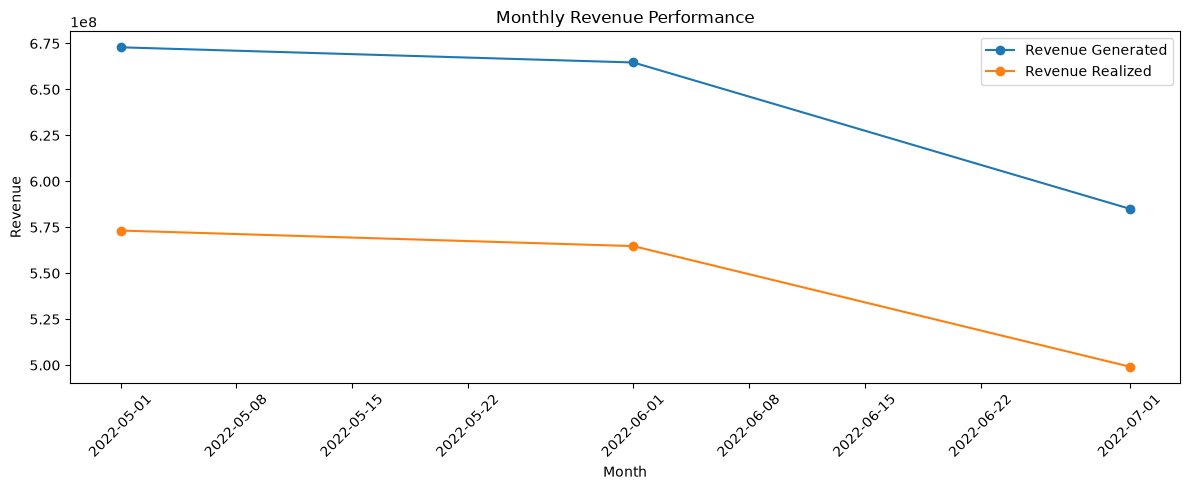

In [147]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_analysis['month_date'],
    monthly_analysis['revenue_generated'],
    marker='o',
    label='Revenue Generated'
)

plt.plot(
    monthly_analysis['month_date'],
    monthly_analysis['revenue_realized'],
    marker='o',
    label='Revenue Realized'
)

plt.title('Monthly Revenue Performance')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [149]:
platform_analysis.columns

Index(['bookings', 'revenue_generated', 'revenue_realized', 'realization_rate',
       'revenue_per_booking'],
      dtype='str')

In [150]:
platform_chart = platform_analysis.reset_index()

In [151]:
platform_chart.columns

Index(['booking_platform', 'bookings', 'revenue_generated', 'revenue_realized',
       'realization_rate', 'revenue_per_booking'],
      dtype='str')

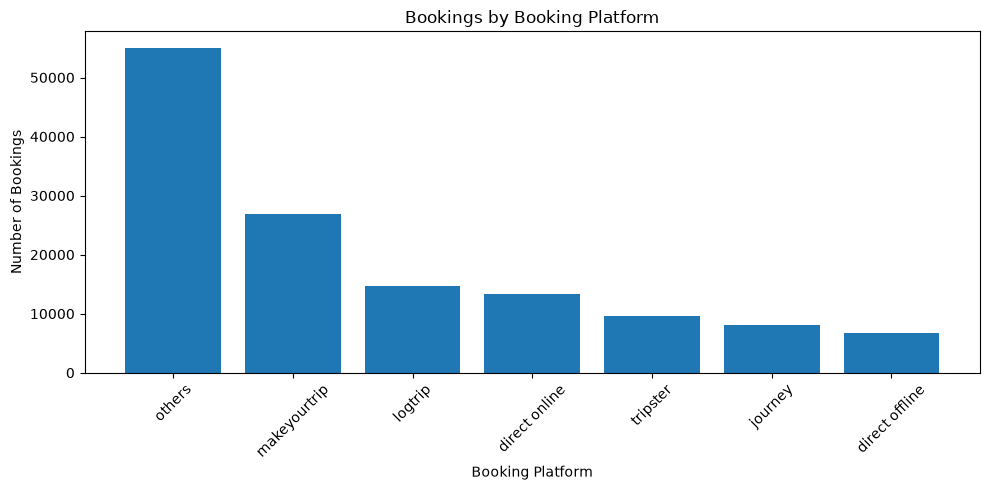

In [152]:
platform_chart = platform_chart.sort_values(
    'bookings',
    ascending=False
)

plt.figure(figsize=(10, 5))

plt.bar(
    platform_chart['booking_platform'],
    platform_chart['bookings']
)

plt.title('Bookings by Booking Platform')
plt.xlabel('Booking Platform')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [153]:
platform_chart = platform_analysis.reset_index()

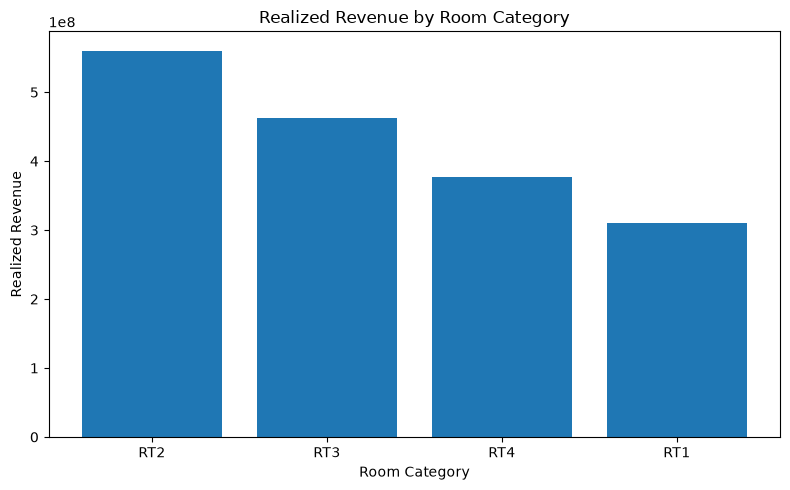

In [154]:
room_chart = room_analysis.reset_index()

room_chart = room_chart.sort_values(
    'revenue_realized',
    ascending=False
)

plt.figure(figsize=(8, 5))

plt.bar(
    room_chart['room_category'],
    room_chart['revenue_realized']
)

plt.title('Realized Revenue by Room Category')
plt.xlabel('Room Category')
plt.ylabel('Realized Revenue')

plt.tight_layout()
plt.show()

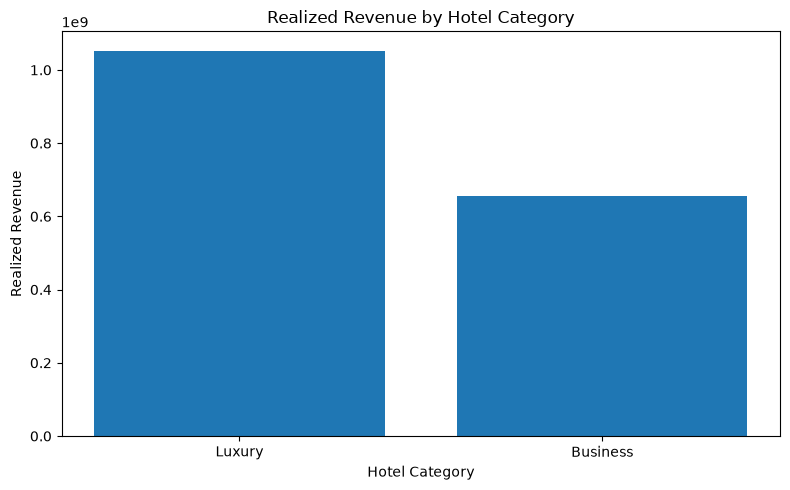

In [155]:
category_chart = category_analysis.copy()

category_chart = category_chart.sort_values(
    'revenue_realized',
    ascending=False
)

plt.figure(figsize=(8, 5))

plt.bar(
    category_chart['category'],
    category_chart['revenue_realized']
)

plt.title('Realized Revenue by Hotel Category')
plt.xlabel('Hotel Category')
plt.ylabel('Realized Revenue')

plt.tight_layout()
plt.show()

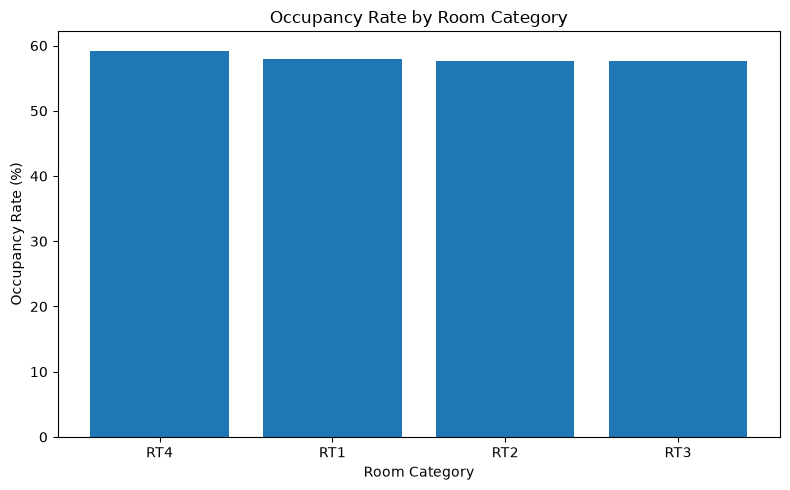

In [156]:
occupancy_chart = occupancy_by_room.sort_values(
    'occupancy_rate',
    ascending=False
)

plt.figure(figsize=(8, 5))

plt.bar(
    occupancy_chart['room_category'],
    occupancy_chart['occupancy_rate']
)

plt.title('Occupancy Rate by Room Category')
plt.xlabel('Room Category')
plt.ylabel('Occupancy Rate (%)')

plt.tight_layout()
plt.show()

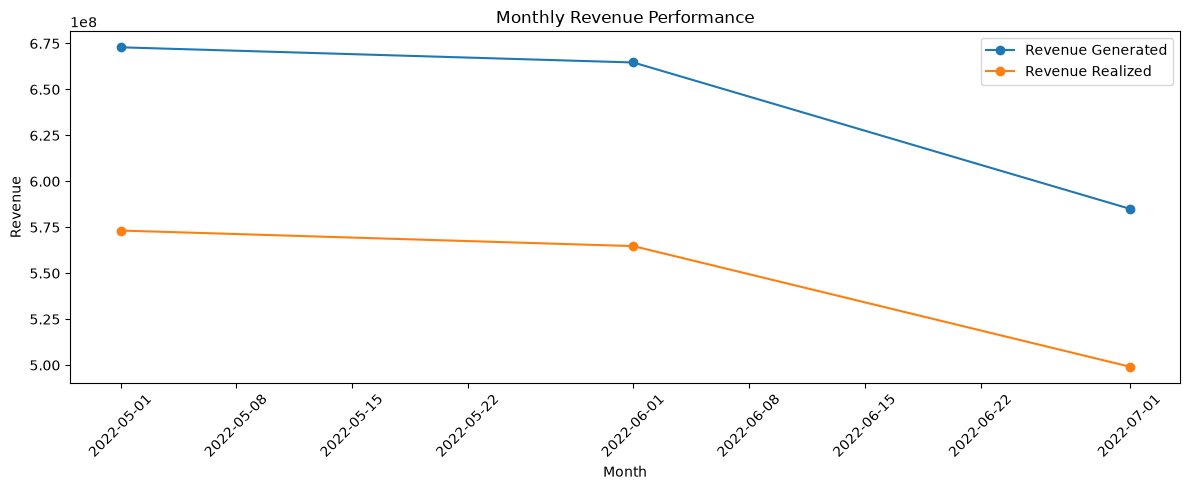

In [157]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_analysis['month_date'],
    monthly_analysis['revenue_generated'],
    marker='o',
    label='Revenue Generated'
)

plt.plot(
    monthly_analysis['month_date'],
    monthly_analysis['revenue_realized'],
    marker='o',
    label='Revenue Realized'
)

plt.title('Monthly Revenue Performance')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

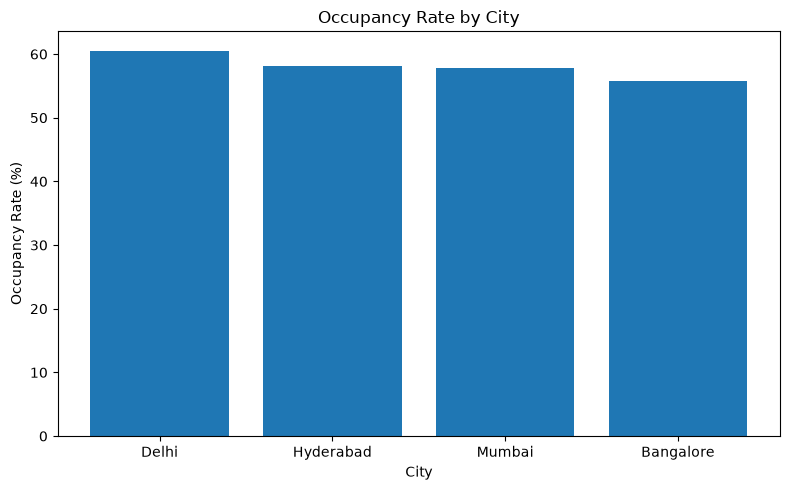

In [158]:
city_occ_chart = city_occupancy.sort_values(
    'occupancy_rate',
    ascending=False
)

plt.figure(figsize=(8, 5))

plt.bar(
    city_occ_chart['city'],
    city_occ_chart['occupancy_rate']
)

plt.title('Occupancy Rate by City')
plt.xlabel('City')
plt.ylabel('Occupancy Rate (%)')

plt.tight_layout()
plt.show()

In [159]:
city_occupancy.sort_values(
    'occupancy_rate',
    ascending=False
).round(2)

,city,successful_bookings,capacity,occupancy_rate
1,Delhi,24231,40020,60.55
2,Hyderabad,34888,60076,58.07
3,Mumbai,43455,75072,57.88
0,Bangalore,32016,57408,55.77


# 3. SQL Analysis – Hospitality Revenue Analysis

In this section, we will analyze the Hospitality Revenue dataset using SQL and MySQL.

### Analysis Areas
- Revenue performance
- Booking status
- Booking platforms
- Hotel categories
- Cities
- Room categories
- Monthly trends
- Revenue realization
- Property-level performance

## 3.1 SQL Setup

Connect the Jupyter Notebook to the `hospitality_analysis` MySQL database using MySQL Connector for Python.

In [171]:
import mysql.connector
import pandas as pd

print("Libraries imported successfully!")

Libraries imported successfully!


## 3.2 Connect Python to MySQL

Establish a connection between Python and the MySQL `hospitality_analysis` database.

In [172]:
conn = mysql.connector.connect(
    host="127.0.0.1",
    user="hotel_user",
    password="Mahii1610",
    database="hospitality_analysis"
)

print("MySQL connected successfully!")

MySQL connected successfully!


## 3.3 Create a Reusable SQL Query Function

Create a function to execute SQL queries and return the results as a Pandas DataFrame.

In [173]:
def run_query(query):
    cursor = conn.cursor(dictionary=True)
    cursor.execute(query)
    result = cursor.fetchall()
    cursor.close()
    return pd.DataFrame(result)

## 3.4 Verify MySQL Connection

Verify the MySQL server, current user, and selected database.

In [175]:
run_query("""
SELECT
    VERSION() AS mysql_version,
    USER() AS logged_in_user,
    DATABASE() AS selected_database;
""")

,mysql_version,logged_in_user,selected_database
0,8.0.46,hotel_user@localhost,hospitality_analysis


## 3.5 Explore Database Tables

Check the tables available in the `hospitality_analysis` database.

In [176]:
run_query("""
SHOW TABLES;
""")

,Tables_in_hospitality_analysis
0,fact_bookings


## 3.6 Inspect the Fact Bookings Table

The `fact_bookings` table contains the booking-level data used for the main revenue analysis.

In [177]:
run_query("""
DESCRIBE fact_bookings;
""")

,Field,Type,Null,Key,Default,Extra
0,booking_id,varchar(50),YES,,None,
1,property_id,int,YES,,None,
2,booking_date,date,YES,,None,
3,check_in_date,date,YES,,None,
4,checkout_date,date,YES,,None,
5,no_guests,int,YES,,None,
6,room_category,varchar(20),YES,,None,
7,booking_platform,varchar(50),YES,,None,
8,ratings_given,varchar(10),YES,,None,
9,booking_status,varchar(30),YES,,None,


## 3.7 View Sample Booking Records

View a small sample of records from the fact bookings table.

In [178]:
run_query("""
SELECT *
FROM fact_bookings
LIMIT 10;
""")

""


## 3.8 Count Total Booking Records

Calculate the total number of booking records available in the dataset.

In [180]:
import pandas as pd
import numpy as np

csv_path = r"C:\Users\ELCOT\Downloads\Hospitality-Revenue-Analysis\HotelAnalytics\fact_bookings.csv"

df_bookings = pd.read_csv(csv_path)

print("Rows:", len(df_bookings))
print("Columns:", df_bookings.columns.tolist())

Rows: 134590
Columns: ['booking_id', 'property_id', 'booking_date', 'check_in_date', 'checkout_date', 'no_guests', 'room_category', 'booking_platform', 'ratings_given', 'booking_status', 'revenue_generated', 'revenue_realized']


In [181]:
cursor = conn.cursor()

insert_query = """
INSERT INTO fact_bookings (
    booking_id,
    property_id,
    booking_date,
    check_in_date,
    checkout_date,
    no_guests,
    room_category,
    booking_platform,
    ratings_given,
    booking_status,
    revenue_generated,
    revenue_realized
)
VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s)
"""

df_insert = df_bookings.replace({np.nan: None})

data = [tuple(row) for row in df_insert.itertuples(index=False, name=None)]

cursor.executemany(insert_query, data)
conn.commit()

print(f"{cursor.rowcount} rows inserted successfully!")

cursor.close()

134590 rows inserted successfully!


True

In [182]:
run_query("""
SELECT COUNT(*) AS total_bookings
FROM fact_bookings;
""")

,total_bookings
0,134590


## 3.9 Data Quality Check

Check important columns for missing values in the `fact_bookings` table.
This helps ensure that the data is suitable for further analysis.

In [200]:
run_query("""
SELECT
    COUNT(*) AS total_rows,
    COUNT(booking_id) AS booking_id_count,
    COUNT(property_id) AS property_id_count,
    COUNT(booking_date) AS booking_date_count,
    COUNT(check_in_date) AS check_in_date_count,
    COUNT(checkout_date) AS checkout_date_count,
    COUNT(revenue_generated) AS revenue_generated_count,
    COUNT(revenue_realized) AS revenue_realized_count
FROM fact_bookings;
""")

,total_rows,booking_id_count,property_id_count,booking_date_count,check_in_date_count,checkout_date_count,revenue_generated_count,revenue_realized_count
0,134590,134590,134590,134590,134590,134590,134590,134590


In [201]:
run_query("""
SELECT
    COUNT(*) AS total_rows,
    COUNT(*) - COUNT(booking_id) AS missing_booking_id,
    COUNT(*) - COUNT(property_id) AS missing_property_id,
    COUNT(*) - COUNT(booking_date) AS missing_booking_date,
    COUNT(*) - COUNT(check_in_date) AS missing_check_in_date,
    COUNT(*) - COUNT(checkout_date) AS missing_checkout_date,
    COUNT(*) - COUNT(revenue_generated) AS missing_revenue_generated,
    COUNT(*) - COUNT(revenue_realized) AS missing_revenue_realized
FROM fact_bookings;
""")

,total_rows,missing_booking_id,missing_property_id,missing_booking_date,missing_check_in_date,missing_checkout_date,missing_revenue_generated,missing_revenue_realized
0,134590,0,0,0,0,0,0,0


## 3.10 View Sample Booking Records

Retrieve a sample of booking records to understand the structure and values in the dataset.

In [184]:
run_query("""
SELECT
    booking_id,
    property_id,
    booking_date,
    booking_status,
    revenue_generated,
    revenue_realized
FROM fact_bookings
LIMIT 10;
""")

,booking_id,property_id,booking_date,booking_status,revenue_generated,revenue_realized
0,May012216558RT11,16558,2022-04-27,Checked Out,10010,10010
1,May012216558RT12,16558,2022-04-30,Cancelled,9100,3640
2,May012216558RT13,16558,2022-04-28,Checked Out,9100,9100
3,May012216558RT14,16558,2022-04-28,Cancelled,9100,3640
4,May012216558RT15,16558,2022-04-27,Checked Out,10920,10920
5,May012216558RT16,16558,2022-05-01,Checked Out,9100,9100
6,May012216558RT17,16558,2022-04-28,Cancelled,9100,3640
7,May012216558RT18,16558,2022-04-26,No Show,9100,9100
8,May012216558RT19,16558,2022-04-30,Checked Out,9100,9100
9,May012216558RT110,16558,2022-04-28,Checked Out,9100,9100


## 3.11 Filtering Data Using WHERE

Use the `WHERE` clause to retrieve bookings based on a specific condition.

In [185]:
run_query("""
SELECT
    booking_id,
    property_id,
    booking_status,
    revenue_realized
FROM fact_bookings
WHERE booking_status = 'Cancelled'
LIMIT 10;
""")

,booking_id,property_id,booking_status,revenue_realized
0,May012216558RT12,16558,Cancelled,3640
1,May012216558RT14,16558,Cancelled,3640
2,May012216558RT17,16558,Cancelled,3640
3,May012216558RT114,16558,Cancelled,3640
4,May012216558RT24,16558,Cancelled,5544
5,May012216558RT25,16558,Cancelled,5040
6,May012216558RT27,16558,Cancelled,5544
7,May012216558RT211,16558,Cancelled,5040
8,May012216558RT217,16558,Cancelled,6048
9,May012216558RT41,16558,Cancelled,10640


## 3.12 Booking Status Analysis

Analyze the number of bookings for each booking status.

In [186]:
run_query("""
SELECT
    booking_status,
    COUNT(*) AS bookings
FROM fact_bookings
GROUP BY booking_status
ORDER BY bookings DESC;
""")

,booking_status,bookings
0,Checked Out,94411
1,Cancelled,33420
2,No Show,6759


## 3.13 Booking Status Revenue Analysis

Compare booking volume and revenue performance across different booking statuses.

In [187]:
run_query("""
SELECT
    booking_status,
    COUNT(*) AS bookings,
    SUM(revenue_generated) AS revenue_generated,
    SUM(revenue_realized) AS revenue_realized
FROM fact_bookings
GROUP BY booking_status
ORDER BY revenue_realized DESC;
""")

,booking_status,bookings,revenue_generated,revenue_realized
0,Checked Out,94411,1409113965,1409113965
1,Cancelled,33420,497958310,199183324
2,No Show,6759,100473940,100473940


## 3.14 Overall Revenue Performance

Calculate total revenue generated, revenue realized, revenue gap, and the overall realization rate.

In [188]:
run_query("""
SELECT
    SUM(revenue_generated) AS revenue_generated,
    SUM(revenue_realized) AS revenue_realized,
    SUM(revenue_generated - revenue_realized) AS revenue_gap,
    ROUND(
        SUM(revenue_realized) / NULLIF(SUM(revenue_generated), 0) * 100,
        2
    ) AS realization_rate
FROM fact_bookings;
""")

,revenue_generated,revenue_realized,revenue_gap,realization_rate
0,2007546215,1708771229,298774986,85.12


## 3.15 Booking Platform Analysis

Analyze booking volume and revenue performance across different booking platforms.
This helps identify which platforms contribute the most bookings and revenue.

In [189]:
run_query("""
SELECT
    booking_platform,
    COUNT(*) AS bookings,
    SUM(revenue_generated) AS revenue_generated,
    SUM(revenue_realized) AS revenue_realized,
    ROUND(
        SUM(revenue_realized) / NULLIF(SUM(revenue_generated), 0) * 100,
        2
    ) AS realization_rate
FROM fact_bookings
GROUP BY booking_platform
ORDER BY bookings DESC;
""")

,booking_platform,bookings,revenue_generated,revenue_realized,realization_rate
0,others,55066,821066620,699353302,85.18
1,makeyourtrip,26898,401502130,340834504,84.89
2,logtrip,14756,219478955,187554488,85.45
3,direct online,13379,198770030,169026467,85.04
4,tripster,9630,144714510,123066801,85.04
5,journey,8106,120654715,102531334,84.98
6,direct offline,6755,101359255,86404333,85.25


## 3.16 Hotel Category Analysis

Analyze booking volume and revenue performance across different hotel categories.
This helps identify which hotel categories contribute the most to overall revenue.

## 3.16.1 Check Available Tables

Identify the tables currently available in the `hospitality_analysis` database before performing joins.

In [192]:
run_query("""
SHOW TABLES;
""")

,Tables_in_hospitality_analysis
0,fact_bookings


## 3.16.2 Inspect Fact Bookings Columns

Check the available columns in the main booking table before creating joins.

In [193]:
run_query("""
DESCRIBE fact_bookings;
""")

,Field,Type,Null,Key,Default,Extra
0,booking_id,varchar(50),YES,,None,
1,property_id,int,YES,,None,
2,booking_date,date,YES,,None,
3,check_in_date,date,YES,,None,
4,checkout_date,date,YES,,None,
5,no_guests,int,YES,,None,
6,room_category,varchar(20),YES,,None,
7,booking_platform,varchar(50),YES,,None,
8,ratings_given,varchar(10),YES,,None,
9,booking_status,varchar(30),YES,,None,


In [195]:
run_query("""
SHOW TABLES;
""")

,Tables_in_hospitality_analysis
0,fact_bookings


In [196]:
run_query("""
SELECT *
FROM fact_bookings
LIMIT 5;
""")

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
0,May012216558RT11,16558,2022-04-27,2022-05-01,2022-05-02,3,RT1,direct online,1.0,Checked Out,10010,10010
1,May012216558RT12,16558,2022-04-30,2022-05-01,2022-05-02,2,RT1,others,NaN,Cancelled,9100,3640
2,May012216558RT13,16558,2022-04-28,2022-05-01,2022-05-04,2,RT1,logtrip,5.0,Checked Out,9100,9100
3,May012216558RT14,16558,2022-04-28,2022-05-01,2022-05-02,2,RT1,others,NaN,Cancelled,9100,3640
4,May012216558RT15,16558,2022-04-27,2022-05-01,2022-05-02,4,RT1,direct online,5.0,Checked Out,10920,10920


In [197]:
hotels.columns.tolist()

['property_id', 'property_name', 'category', 'city']

In [199]:
import mysql.connector
import pandas as pd

conn = mysql.connector.connect(
    host="127.0.0.1",
    user="root",
    password="Mahesh@1234",
    database="hospitality_analysis"
)

print("MySQL connected successfully!")

MySQL connected successfully!


### 3.16.3 Create Hotels Table

Create a MySQL table for hotel/property information so that it can be joined with the `fact_bookings` table using `property_id`.

In [202]:
cursor = conn.cursor()

cursor.execute("""
CREATE TABLE IF NOT EXISTS hotels (
    property_id INT,
    property_name VARCHAR(100),
    category VARCHAR(50),
    city VARCHAR(50)
);
""")

conn.commit()

print("Hotels table created successfully!")

Hotels table created successfully!


### 3.16.4 Load Hotel Data into MySQL

Insert the hotel information from the Pandas DataFrame into the MySQL `hotels` table.

In [203]:
cursor = conn.cursor()

# Clear existing records if the cell is run again
cursor.execute("TRUNCATE TABLE hotels")

insert_query = """
INSERT INTO hotels
(property_id, property_name, category, city)
VALUES (%s, %s, %s, %s)
"""

data = [
    (
        int(row.property_id),
        row.property_name,
        row.category,
        row.city
    )
    for row in hotels.itertuples(index=False)
]

cursor.executemany(insert_query, data)
conn.commit()

print(f"{cursor.rowcount} hotel records inserted successfully!")

25 hotel records inserted successfully!


### 3.16.5 Verify Hotels Table

Verify that the hotel records were successfully loaded into MySQL.

In [204]:
run_query("""
SELECT *
FROM hotels
LIMIT 10;
""")

,property_id,property_name,category,city
0,16558,Atliq Grands,Luxury,Delhi
1,16559,Atliq Exotica,Luxury,Mumbai
2,16560,Atliq City,Business,Delhi
3,16561,Atliq Blu,Luxury,Delhi
4,16562,Atliq Bay,Luxury,Delhi
5,16563,Atliq Palace,Business,Delhi
6,17558,Atliq Grands,Luxury,Mumbai
7,17559,Atliq Exotica,Luxury,Mumbai
8,17560,Atliq City,Business,Mumbai
9,17561,Atliq Blu,Luxury,Mumbai


### 3.16.6 Verify Available Tables

Check that both the booking and hotel tables are available before creating joins.

In [205]:
run_query("""
SHOW TABLES;
""")

,Tables_in_hospitality_analysis
0,fact_bookings
1,hotels


### 3.17 Join Bookings with Hotel Information

Join the `fact_bookings` table with the `hotels` table using `property_id` to combine booking and hotel information.

In [206]:
run_query("""
SELECT
    f.booking_id,
    f.property_id,
    h.property_name,
    h.category,
    h.city,
    f.booking_date,
    f.booking_status,
    f.revenue_generated,
    f.revenue_realized
FROM fact_bookings f
JOIN hotels h
    ON f.property_id = h.property_id
LIMIT 10;
""")

,booking_id,property_id,property_name,category,city,booking_date,booking_status,revenue_generated,revenue_realized
0,May012216558RT11,16558,Atliq Grands,Luxury,Delhi,2022-04-27,Checked Out,10010,10010
1,May012216558RT12,16558,Atliq Grands,Luxury,Delhi,2022-04-30,Cancelled,9100,3640
2,May012216558RT13,16558,Atliq Grands,Luxury,Delhi,2022-04-28,Checked Out,9100,9100
3,May012216558RT14,16558,Atliq Grands,Luxury,Delhi,2022-04-28,Cancelled,9100,3640
4,May012216558RT15,16558,Atliq Grands,Luxury,Delhi,2022-04-27,Checked Out,10920,10920
5,May012216558RT16,16558,Atliq Grands,Luxury,Delhi,2022-05-01,Checked Out,9100,9100
6,May012216558RT17,16558,Atliq Grands,Luxury,Delhi,2022-04-28,Cancelled,9100,3640
7,May012216558RT18,16558,Atliq Grands,Luxury,Delhi,2022-04-26,No Show,9100,9100
8,May012216558RT19,16558,Atliq Grands,Luxury,Delhi,2022-04-30,Checked Out,9100,9100
9,May012216558RT110,16558,Atliq Grands,Luxury,Delhi,2022-04-28,Checked Out,9100,9100


### 3.18 Property-Level Revenue Performance

Analyze booking volume and revenue performance for each hotel property.

In [207]:
run_query("""
SELECT
    h.property_id,
    h.property_name,
    h.city,
    COUNT(*) AS total_bookings,
    SUM(f.revenue_generated) AS revenue_generated,
    SUM(f.revenue_realized) AS revenue_realized,
    ROUND(
        SUM(f.revenue_realized) /
        NULLIF(SUM(f.revenue_generated), 0) * 100,
        2
    ) AS realization_rate
FROM fact_bookings f
JOIN hotels h
    ON f.property_id = h.property_id
GROUP BY
    h.property_id,
    h.property_name,
    h.city
ORDER BY revenue_realized DESC;
""")

,property_id,property_name,city,total_bookings,revenue_generated,revenue_realized,realization_rate
0,16559,Atliq Exotica,Mumbai,7338,138698580,118448418,85.40
1,17563,Atliq Palace,Mumbai,6337,118616735,101511080,85.58
2,17559,Atliq Exotica,Mumbai,6142,109696920,93996570,85.69
3,16563,Atliq Palace,Delhi,7147,105200620,89135998,84.73
4,17560,Atliq City,Mumbai,6013,103776330,87996216,84.79
5,19562,Atliq Bay,Bangalore,5812,96540375,82443540,85.40
6,19560,Atliq City,Bangalore,5979,97486125,81876345,83.99
7,17558,Atliq Grands,Mumbai,5036,88430770,74730742,84.51
8,17561,Atliq Blu,Mumbai,5183,86646790,73918312,85.31
9,19561,Atliq Blu,Bangalore,5736,85807575,72963360,85.03


### 3.19 City-Level Revenue Performance

Analyze booking volume and revenue performance across different cities.

In [208]:
run_query("""
SELECT
    h.city,
    COUNT(*) AS total_bookings,
    SUM(f.revenue_generated) AS revenue_generated,
    SUM(f.revenue_realized) AS revenue_realized,
    ROUND(
        SUM(f.revenue_realized) /
        NULLIF(SUM(f.revenue_generated), 0) * 100,
        2
    ) AS realization_rate
FROM fact_bookings f
JOIN hotels h
    ON f.property_id = h.property_id
GROUP BY h.city
ORDER BY revenue_realized DESC;
""")

,city,total_bookings,revenue_generated,revenue_realized,realization_rate
0,Mumbai,43455,784865350,668640991,85.19
1,Bangalore,32016,494828175,420397050,84.96
2,Hyderabad,34888,381400850,325232870,85.27
3,Delhi,24231,346451840,294500318,85.00


### 3.20 Booking Status Performance

Analyze the number of bookings and revenue performance by booking status.

In [209]:
run_query("""
SELECT
    booking_status,
    COUNT(*) AS total_bookings,
    SUM(revenue_generated) AS revenue_generated,
    SUM(revenue_realized) AS revenue_realized,
    ROUND(
        SUM(revenue_realized) /
        NULLIF(SUM(revenue_generated), 0) * 100,
        2
    ) AS realization_rate
FROM fact_bookings
GROUP BY booking_status
ORDER BY total_bookings DESC;
""")

,booking_status,total_bookings,revenue_generated,revenue_realized,realization_rate
0,Checked Out,94411,1409113965,1409113965,100.00
1,Cancelled,33420,497958310,199183324,40.00
2,No Show,6759,100473940,100473940,100.00


### 3.21 Booking Platform Performance

Analyze booking volume and revenue performance across different booking platforms.

In [210]:
run_query("""
SELECT
    booking_platform,
    COUNT(*) AS total_bookings,
    SUM(revenue_generated) AS revenue_generated,
    SUM(revenue_realized) AS revenue_realized,
    ROUND(
        SUM(revenue_realized) /
        NULLIF(SUM(revenue_generated), 0) * 100,
        2
    ) AS realization_rate
FROM fact_bookings
GROUP BY booking_platform
ORDER BY revenue_realized DESC;
""")

,booking_platform,total_bookings,revenue_generated,revenue_realized,realization_rate
0,others,55066,821066620,699353302,85.18
1,makeyourtrip,26898,401502130,340834504,84.89
2,logtrip,14756,219478955,187554488,85.45
3,direct online,13379,198770030,169026467,85.04
4,tripster,9630,144714510,123066801,85.04
5,journey,8106,120654715,102531334,84.98
6,direct offline,6755,101359255,86404333,85.25


### 3.22 Monthly Revenue Trends

Analyze monthly booking volume and revenue performance to identify trends over time.

In [211]:
run_query("""
SELECT
    DATE_FORMAT(booking_date, '%Y-%m') AS month,
    COUNT(*) AS total_bookings,
    SUM(revenue_generated) AS revenue_generated,
    SUM(revenue_realized) AS revenue_realized
FROM fact_bookings
GROUP BY DATE_FORMAT(booking_date, '%Y-%m')
ORDER BY month;
""")

,month,total_bookings,revenue_generated,revenue_realized
0,2022-04,5716,84891900,71613369
1,2022-05,45129,672909985,573219265
2,2022-06,44578,664656710,564754400
3,2022-07,39167,585087620,499184195


### 3.23 Revenue Performance by Hotel Category

Analyze booking volume and revenue performance across different hotel categories.

In [212]:
run_query("""
SELECT
    h.category,
    COUNT(*) AS total_bookings,
    SUM(f.revenue_generated) AS revenue_generated,
    SUM(f.revenue_realized) AS revenue_realized,
    ROUND(
        SUM(f.revenue_realized) /
        NULLIF(SUM(f.revenue_generated), 0) * 100,
        2
    ) AS realization_rate
FROM fact_bookings f
JOIN hotels h
    ON f.property_id = h.property_id
GROUP BY h.category
ORDER BY revenue_realized DESC;
""")

,category,total_bookings,revenue_generated,revenue_realized,realization_rate
0,Luxury,83660,1235337290,1052751932,85.22
1,Business,50930,772208925,656019297,84.95


### 3.24 Revenue Performance by Room Category

Analyze booking volume and revenue performance across different room categories.

In [213]:
run_query("""
SELECT
    room_category,
    COUNT(*) AS total_bookings,
    SUM(revenue_generated) AS revenue_generated,
    SUM(revenue_realized) AS revenue_realized,
    ROUND(
        SUM(revenue_realized) /
        NULLIF(SUM(revenue_generated), 0) * 100,
        2
    ) AS realization_rate
FROM fact_bookings
GROUP BY room_category
ORDER BY revenue_realized DESC;
""")

,room_category,total_bookings,revenue_generated,revenue_realized,realization_rate
0,RT2,49505,658946160,560271204,85.03
1,RT3,30566,543597840,462166344,85.02
2,RT4,16073,441457020,376752786,85.34
3,RT1,38446,363545195,309580895,85.16


### 3.25 Cancellation & No-Show Analysis

Analyze cancelled and no-show bookings to understand their volume and associated revenue impact.

In [214]:
run_query("""
SELECT
    booking_status,
    COUNT(*) AS total_bookings,
    SUM(revenue_generated) AS revenue_generated,
    SUM(revenue_realized) AS revenue_realized,
    SUM(revenue_generated - revenue_realized) AS revenue_gap,
    ROUND(
        COUNT(*) * 100.0 /
        (SELECT COUNT(*) FROM fact_bookings),
        2
    ) AS booking_percentage
FROM fact_bookings
WHERE booking_status IN ('Cancelled', 'No Show')
GROUP BY booking_status
ORDER BY total_bookings DESC;
""")

,booking_status,total_bookings,revenue_generated,revenue_realized,revenue_gap,booking_percentage
0,Cancelled,33420,497958310,199183324,298774986,24.83
1,No Show,6759,100473940,100473940,0,5.02


### 3.26 Revenue Gap Analysis

Analyze the difference between revenue generated and revenue realized to identify the overall revenue gap and realization rate.

In [215]:
run_query("""
SELECT
    SUM(revenue_generated) AS total_revenue_generated,
    SUM(revenue_realized) AS total_revenue_realized,
    SUM(revenue_generated - revenue_realized) AS total_revenue_gap,
    ROUND(
        SUM(revenue_realized) /
        NULLIF(SUM(revenue_generated), 0) * 100,
        2
    ) AS realization_rate
FROM fact_bookings;
""")

,total_revenue_generated,total_revenue_realized,total_revenue_gap,realization_rate
0,2007546215,1708771229,298774986,85.12


### 3.27 Top-Performing Properties

Identify the top-performing hotel properties based on realized revenue.

In [217]:
run_query("""
SELECT
    h.property_id,
    h.property_name,
    h.city,
    COUNT(*) AS total_bookings,
    SUM(f.revenue_generated) AS revenue_generated,
    SUM(f.revenue_realized) AS revenue_realized,
    ROUND(
        SUM(f.revenue_realized) /
        NULLIF(SUM(f.revenue_generated), 0) * 100,
        2
    ) AS realization_rate
FROM fact_bookings f
JOIN hotels h
    ON f.property_id = h.property_id
GROUP BY
    h.property_id,
    h.property_name,
    h.city
ORDER BY revenue_realized DESC
LIMIT 10;
""")

,property_id,property_name,city,total_bookings,revenue_generated,revenue_realized,realization_rate
0,16559,Atliq Exotica,Mumbai,7338,138698580,118448418,85.40
1,17563,Atliq Palace,Mumbai,6337,118616735,101511080,85.58
2,17559,Atliq Exotica,Mumbai,6142,109696920,93996570,85.69
3,16563,Atliq Palace,Delhi,7147,105200620,89135998,84.73
4,17560,Atliq City,Mumbai,6013,103776330,87996216,84.79
5,19562,Atliq Bay,Bangalore,5812,96540375,82443540,85.40
6,19560,Atliq City,Bangalore,5979,97486125,81876345,83.99
7,17558,Atliq Grands,Mumbai,5036,88430770,74730742,84.51
8,17561,Atliq Blu,Mumbai,5183,86646790,73918312,85.31
9,19561,Atliq Blu,Bangalore,5736,85807575,72963360,85.03


### 3.28 Final Business Insights

Summarize the key business insights identified from the SQL analysis, including revenue performance, booking behavior, property performance, booking platforms, hotel categories, and monthly trends.

In [218]:
run_query("""
SELECT
    COUNT(*) AS total_bookings,
    SUM(revenue_generated) AS revenue_generated,
    SUM(revenue_realized) AS revenue_realized,
    SUM(revenue_generated - revenue_realized) AS revenue_gap,
    ROUND(
        SUM(revenue_realized) /
        NULLIF(SUM(revenue_generated), 0) * 100,
        2
    ) AS realization_rate,
    SUM(CASE
        WHEN booking_status = 'Cancelled' THEN 1
        ELSE 0
    END) AS cancelled_bookings,
    SUM(CASE
        WHEN booking_status = 'No Show' THEN 1
        ELSE 0
    END) AS no_show_bookings
FROM fact_bookings;
""")

,total_bookings,revenue_generated,revenue_realized,revenue_gap,realization_rate,cancelled_bookings,no_show_bookings
0,134590,2007546215,1708771229,298774986,85.12,33420,6759


### 3.29 Create Power BI-Ready Dataset

Create a combined dataset by joining booking information with hotel details. This dataset will be used for the Power BI dashboard.

In [220]:
run_query("""
DESCRIBE fact_bookings;
""")

,Field,Type,Null,Key,Default,Extra
0,booking_id,varchar(50),YES,,None,
1,property_id,int,YES,,None,
2,booking_date,date,YES,,None,
3,check_in_date,date,YES,,None,
4,checkout_date,date,YES,,None,
5,no_guests,int,YES,,None,
6,room_category,varchar(20),YES,,None,
7,booking_platform,varchar(50),YES,,None,
8,ratings_given,varchar(10),YES,,None,
9,booking_status,varchar(30),YES,,None,


### 3.29 Create Power BI-Ready Dataset

Create a combined dataset by joining booking information with hotel details. This dataset will be used for the Power BI dashboard.

In [221]:
powerbi_data = run_query("""
SELECT
    f.booking_id,
    f.property_id,
    h.property_name,
    h.category AS hotel_category,
    h.city,
    f.booking_date,
    f.check_in_date,
    f.checkout_date,
    f.booking_status,
    f.room_category,
    f.booking_platform,
    f.revenue_generated,
    f.revenue_realized,
    f.revenue_generated - f.revenue_realized AS revenue_gap
FROM fact_bookings f
JOIN hotels h
    ON f.property_id = h.property_id;
""")

powerbi_data.head()

,booking_id,property_id,property_name,hotel_category,city,booking_date,check_in_date,checkout_date,booking_status,room_category,booking_platform,revenue_generated,revenue_realized,revenue_gap
0,May012216558RT11,16558,Atliq Grands,Luxury,Delhi,2022-04-27,2022-05-01,2022-05-02,Checked Out,RT1,direct online,10010,10010,0
1,May012216558RT12,16558,Atliq Grands,Luxury,Delhi,2022-04-30,2022-05-01,2022-05-02,Cancelled,RT1,others,9100,3640,5460
2,May012216558RT13,16558,Atliq Grands,Luxury,Delhi,2022-04-28,2022-05-01,2022-05-04,Checked Out,RT1,logtrip,9100,9100,0
3,May012216558RT14,16558,Atliq Grands,Luxury,Delhi,2022-04-28,2022-05-01,2022-05-02,Cancelled,RT1,others,9100,3640,5460
4,May012216558RT15,16558,Atliq Grands,Luxury,Delhi,2022-04-27,2022-05-01,2022-05-02,Checked Out,RT1,direct online,10920,10920,0


### 3.29.1 Validate Power BI Dataset

Check the number of records and columns in the final dataset before exporting it.

In [222]:
print("Rows:", powerbi_data.shape[0])
print("Columns:", powerbi_data.shape[1])

powerbi_data.info()

Rows: 134590
Columns: 14
<class 'pandas.DataFrame'>
RangeIndex: 134590 entries, 0 to 134589
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   booking_id         134590 non-null  str   
 1   property_id        134590 non-null  int64 
 2   property_name      134590 non-null  str   
 3   hotel_category     134590 non-null  str   
 4   city               134590 non-null  str   
 5   booking_date       134590 non-null  object
 6   check_in_date      134590 non-null  object
 7   checkout_date      134590 non-null  object
 8   booking_status     134590 non-null  str   
 9   room_category      134590 non-null  str   
 10  booking_platform   134590 non-null  str   
 11  revenue_generated  134590 non-null  int64 
 12  revenue_realized   134590 non-null  int64 
 13  revenue_gap        134590 non-null  int64 
dtypes: int64(4), object(3), str(7)
memory usage: 14.4+ MB


### 3.29.2 Export Dataset for Power BI

Export the final combined dataset as a CSV file for use in Power BI.

In [223]:
powerbi_data.to_csv("hospitality_powerbi_data.csv", index=False)

print("Power BI dataset exported successfully!")

Power BI dataset exported successfully!
